# Decision tree classifier

In [2]:
import pandas as pd
from seaborn import load_dataset
df=load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
#description of data
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,146.000000,146.000000,146.000000,146.000000
mean,5.856849,3.040411,3.806849,1.220548
std,0.834093,0.397853,1.758042,0.759393
min,4.300000,2.200000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.000000,6.900000,2.500000


In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

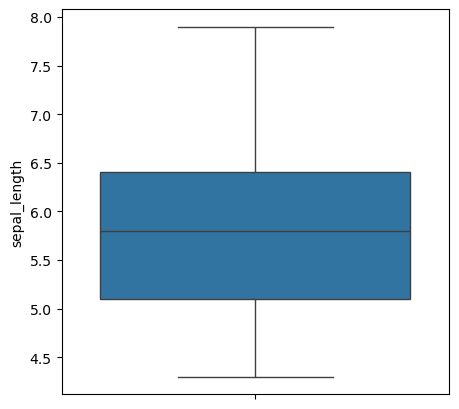

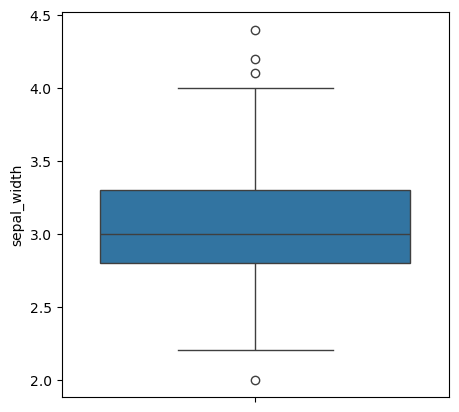

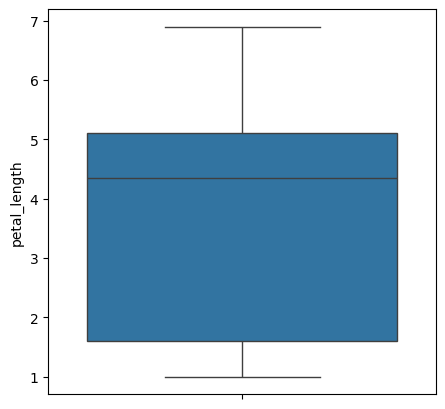

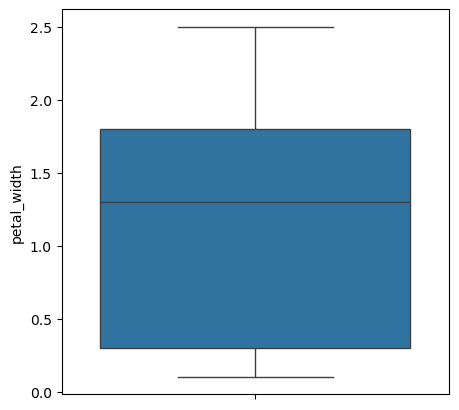

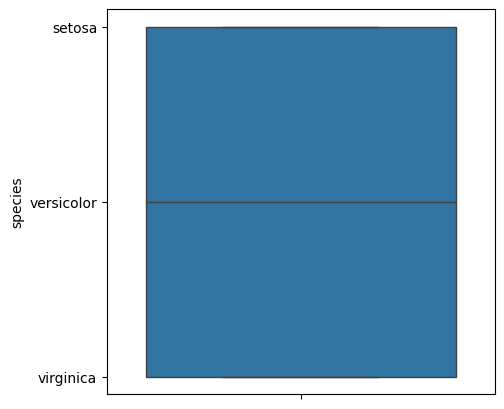

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
for i in df.columns:
    plt.figure(figsize=(5,5))
    sns.boxplot(df[i])
    plt.show()

In [6]:
#remove outliers in sepal_width
Q1=df["sepal_width"].quantile(0.25)
Q3=df["sepal_width"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df=df[(df["sepal_width"]>=lower_bound) & (df["sepal_width"]<=upper_bound)]

In [9]:
from sklearn.model_selection import train_test_split
x=df.drop("species",axis=1)
y=df["species"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
#decison tree classifier
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="entropy",max_depth=5,random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

In [24]:
y_pred=model.predict(x_test)
y_train_pred=model.predict(x_train)
from sklearn.metrics import accuracy_score
print("train accuracy:",accuracy_score(y_train,y_train_pred))
print("test accuracy:",accuracy_score(y_test,y_pred))

train accuracy: 1.0
test accuracy: 0.9333333333333333


In [33]:
#load the iris dataset which also show target column

from sklearn.datasets import load_iris


df = load_iris()
df.target_names
df['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [32]:
df['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [34]:
x=pd.DataFrame(df.data,columns=df.feature_names)
y=pd.DataFrame(df.target,columns=["target"])

In [35]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [36]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [37]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [38]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

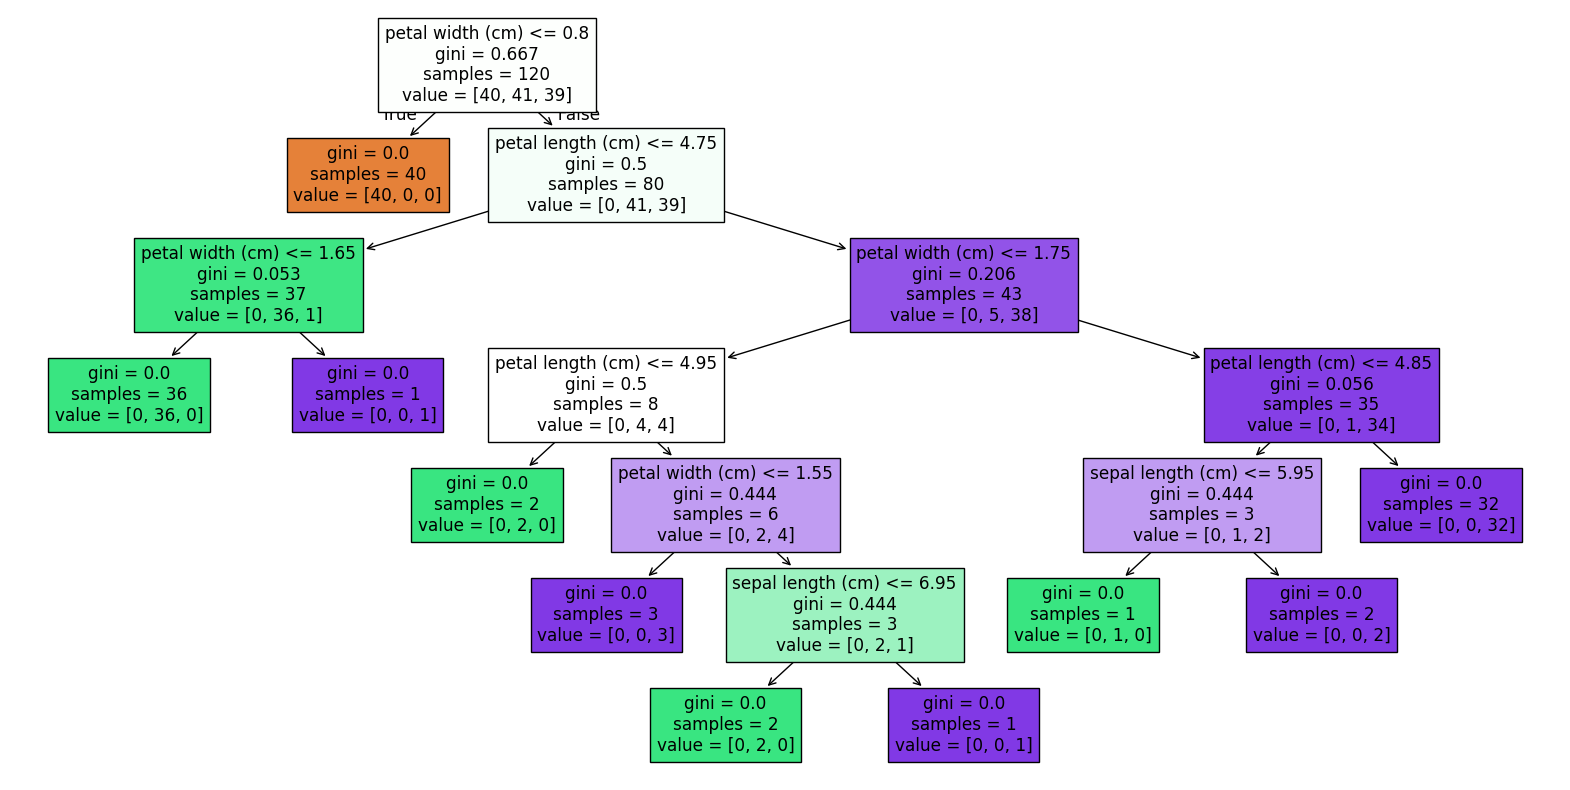

In [49]:
#visualization of decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model,feature_names=x.columns,filled=True)
plt.show()

In [50]:
model2=DecisionTreeClassifier(criterion="entropy",max_depth=5,random_state=42)
model2.fit(x_train,y_train)
y_pred=model2.predict(x_test)


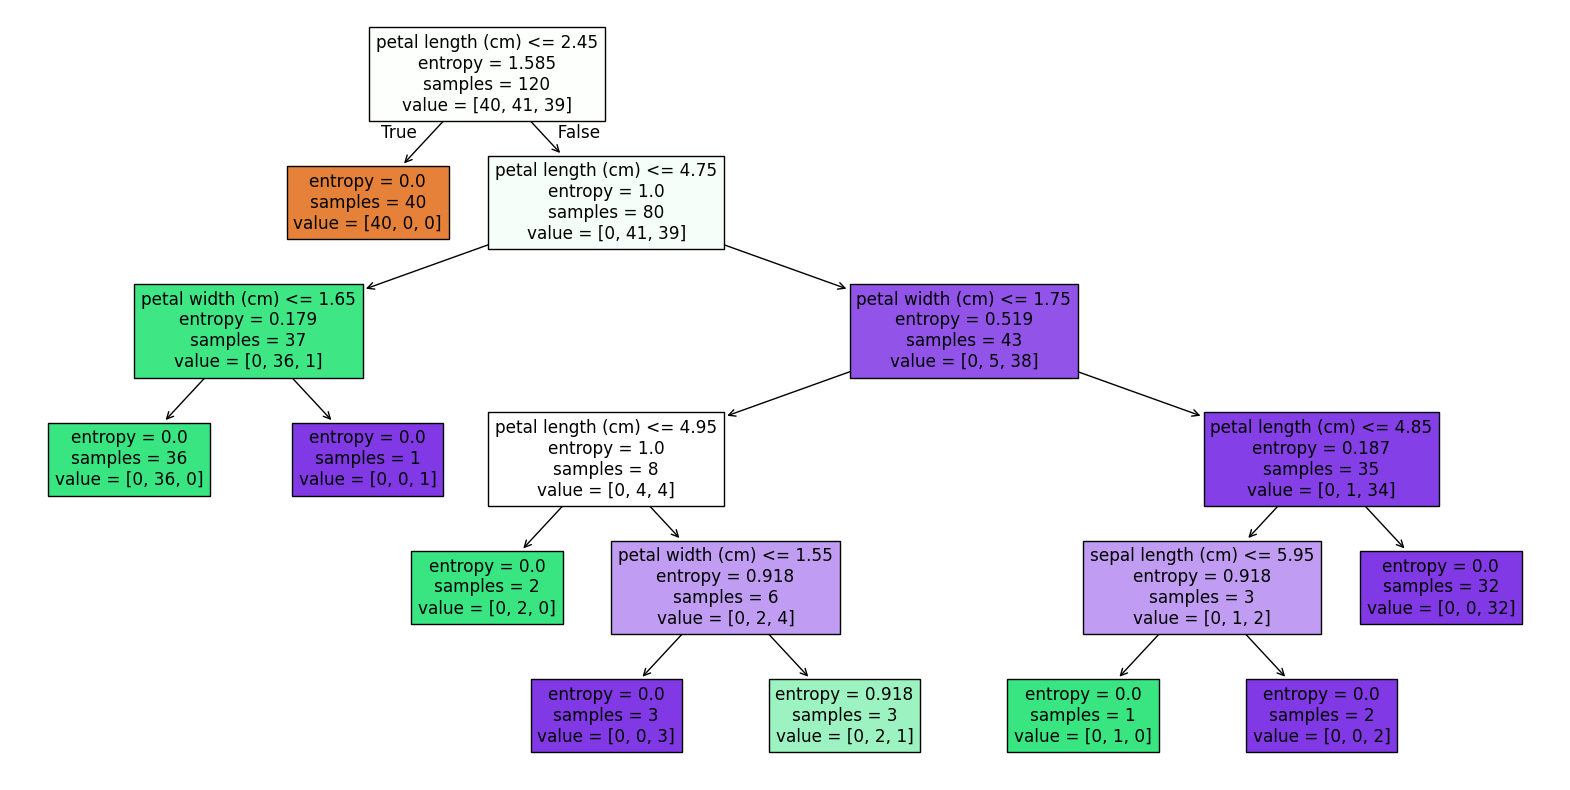

In [51]:
#visualization of decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model2,feature_names=x.columns,filled=True)
plt.show()